# **STAGE 3 - EDA AND VISUALISATION**

## **Objectives**

* Write your notebook objective here, for example, "Fetch data from Kaggle and save as raw data", or "engineer features for modelling"

## **Inputs**

* The data input I need for this section is the cleaned dataset I created in **Stage 2 - ETL**: `datasets/cleaned-data/bank-churners-cleaned.csv`

## Outputs

* Write here which files, code or artefacts you generate by the end of the notebook 


---

## **Change Working Directory**

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'/Users/elliebrawn/Documents/vscode-projects/credit-card-customer-churn-analysis/jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'/Users/elliebrawn/Documents/vscode-projects/credit-card-customer-churn-analysis'

---

## **Import Libraries and Packages**

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg
from scipy import stats
sns.set_style("whitegrid")
sns.set_palette("PiYG", n_colors=6)
colours = sns.color_palette("PiYG", n_colors=2)

---

## **Load the Dataset**

In [5]:
# Load the cleaned dataset
df_vis = pd.read_csv("datasets/cleaned-data/bank-churners-cleaned.csv")

# Display the first few rows of the dataset to make sure the data has loaded correctly
df_vis.head()

,anonymised_clientnum,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Attrition_Flag_Binary
0,022e52f0a251431f954db620fd0c87ac3c523c60cc5980...,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,3,12691.0,777.0,11914.0,1.335,1144.0,42,1.625,0.061,0
1,2731de4ed9ecb2a3ab828448bfda6137e5c7571e1f7576...,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,2,8256.0,864.0,7392.0,1.541,1291.0,33,3.714,0.105,0
2,75dac624c2bbdb15b16abc0350820bcf598c012a76b102...,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,0,3418.0,0.0,3418.0,2.594,1887.0,20,2.333,0.000,0
3,1aaada0cd1f7dc23d83a171beec9f398cfac1471841843...,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,1,3313.0,2517.0,796.0,1.405,1171.0,20,2.333,0.760,0
4,1811f55b3210153f77e41ceceb61cc181d2edc4e65947e...,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,0,4716.0,0.0,4716.0,2.175,816.0,28,2.500,0.000,0


---

## **1. Exploratory Data Analysis (EDA)**

### **1.1 Attrition Flag - Analysis of Target Variable**

Seeing as `Attrition_Flag` (or at least, `Attrition_Flag_Binary`) is going to be the target variable in **Stage 4 - Machine Learning**, it will be good to get a sense of the split between existing and attrited customers.

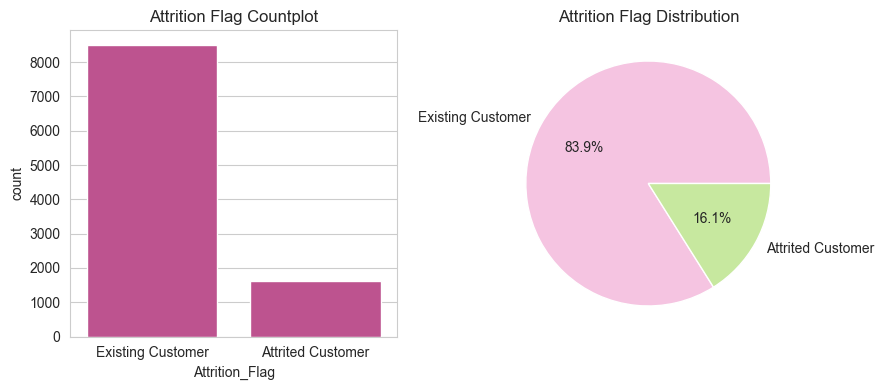

In [7]:
# Map a countplot and pie chart for attrition flag variable
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(9, 4), tight_layout=True)

sns.countplot(data=df_vis, x="Attrition_Flag", ax=axes[0])
axes[0].set_title("Attrition Flag Countplot")

axes[1].pie(
    df_vis["Attrition_Flag"].value_counts(),
    labels=df_vis["Attrition_Flag"].value_counts().index, 
    colors = colours, autopct="%1.1f%%")
axes[1].set_title("Attrition Flag Distribution")

plt.show()

Given what we can see here, the `Attrition_Flag` values are imbalanced. This is very important to note because it affects how we will need to look at machine learning - accuracy alone will not be a good judge of the performance of a machine learning model. 

### **1.2 Demographic Variables - Gender, Marital Status and Education Level**

#### **1.2.1 Countplots for Demographic Variables**

The first thing I am going to do is plot three separate countplots for demographic variables showing those attrited vs not.

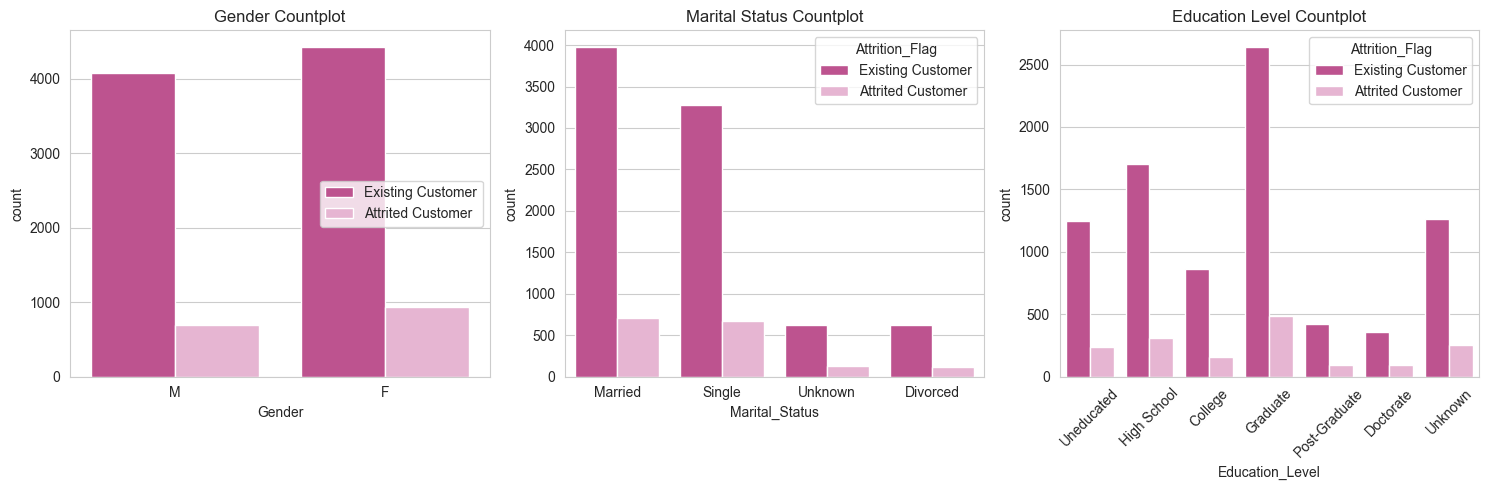

In [8]:
# Map a countplot for demographic variables Gender, Marital_Status and Education_Level
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5), tight_layout=True)

# Plot countplot for Gender
sns.countplot(data=df_vis, x="Gender", hue="Attrition_Flag", ax=axes[0])
axes[0].set_title("Gender Countplot")
axes[0].legend(loc="center right")

# Plot countplot for Marital_Status
sns.countplot(data=df_vis, x="Marital_Status", hue="Attrition_Flag", ax=axes[1])
axes[1].set_title("Marital Status Countplot")

# Set order of the Education_Level variable to ensure "Unknown" is at the end
education_level_order = [
    "Uneducated",
    "High School",
    "College",
    "Graduate",
    "Post-Graduate",
    "Doctorate",
    "Unknown"
]

# Plot countplot for Education_Level
sns.countplot(data=df_vis, x="Education_Level", order=education_level_order, hue="Attrition_Flag", ax=axes[2])
axes[2].set_title("Education Level Countplot")
axes[2].tick_params(axis='x', rotation=45)

plt.show()

> *Notes on Process*: 
<br><br>The following [Stack Overflow](https://stackoverflow.com/questions/10998621/rotate-axis-tick-labels) forum was incredibly helpful in finding out how to rotate my x-ticks to make them fit.
<br><br>I used the [Matplotlib Documentation](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.legend.html) for `.legend` to move the legend in the Gender plot to allow viewers to see the top of the bar.
<br><br>

#### **1.2.2 Proportion Bar Charts**

The biggest problem with these three countplots is that because the `Attrition_Flag` variable is so imbalanced (Existing Customers make up nearly 84% and Attrited just over 16%), the countplots essentially just reflect this imbalance and there's not a lot of *new* information we can take away. It is very difficult to see if there is any difference in the proportions between categories:
* e.g. Is there a bigger proportion of Attrited Customers in the `Married` category vs in the `Single` category for `Marital_Status`?

I am therefore going to create three separate proportion bar charts which will show, within each category in `Gender`/`Marital_Status`/`Education_Level`, what proportion is existing vs attrited. This will allow me to measure attrition rate across groups fairly.

> *Notes on Process*: 
<br><br>This was a new concept to me, so it involved a lot of research to work out how best to manage this. A massive help in terms of knowing what to do was this [Stack Overflow](https://stackoverflow.com/questions/34615854/countplot-with-normalized-y-axis-per-group) forum. I had to use Generative AI (Claude Sonnet 5) to research some of the methods applied to my `df_vis`, including why the order of the methods mattered.
<br><br>Particularly important is the order of `.groupby` *followed by* `value_counts(normalize=True)`. Because `normalize=True` converts each count into a proportion of the total, it was essential to use `.groupby()` first.
<br><br>To clarify the process more clearly, I have ensured to include comments to outline each process.

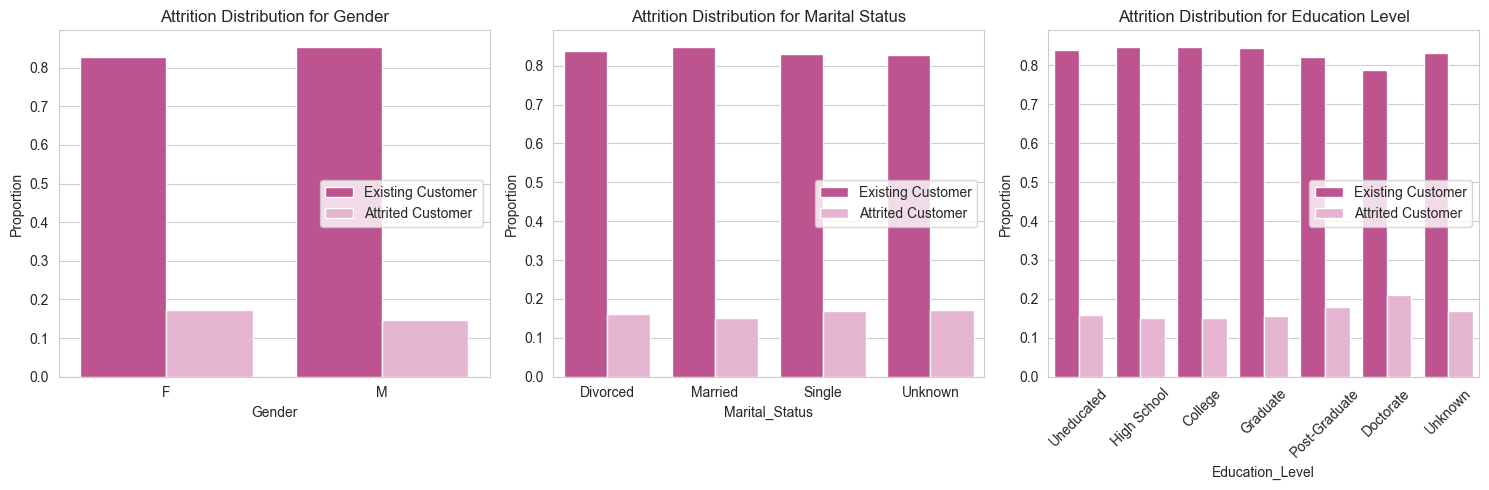

In [9]:
# Map a barplot of proportions for demographic variables Gender, Marital_Status and Education_Level
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5), tight_layout=True)

# Attrition_Flag Distribution by Gender
gender_attrition_proportions = (df_vis.groupby('Gender')['Attrition_Flag'] # Split the data by Gender category (M and F) and pull out just the Attrition_Flag data
                                .value_counts(normalize=True) # Within each Gender Category, calculate the proportion of each Attrition_Flag category (Existing Customer and Attrited Customer)
                                .rename("Proportion")
                                .reset_index())

# Plot Attrition_Flag Distribution by Gender in a barplot
sns.barplot(data=gender_attrition_proportions, x='Gender', y='Proportion', hue='Attrition_Flag', ax=axes[0])
axes[0].set_title("Attrition Distribution for Gender")
axes[0].legend(loc="center right")

# Attrition_Flag Distribution by Marital_Status
marital_attrition_proportions = (df_vis.groupby('Marital_Status')['Attrition_Flag'] # Split the data by Marital_Status category and pull out just the Attrition_Flag data
                                .value_counts(normalize=True) # Within each Marital_Status Category, calculate the proportion of each Attrition_Flag category (Existing Customer and Attrited Customer)
                                .rename("Proportion")
                                .reset_index())

# Plot Attrition_Flag Distribution by Marital_Status in a barplot
sns.barplot(data=marital_attrition_proportions, x='Marital_Status', y='Proportion', hue='Attrition_Flag', ax=axes[1])
axes[1].set_title("Attrition Distribution for Marital Status")
axes[1].legend(loc="center right")

# Attrition_Flag Distribution by Education_Level
education_attrition_proportions = (df_vis.groupby('Education_Level')['Attrition_Flag'] # Split the data by Education_Level category and pull out just the Attrition_Flag data
                                    .value_counts(normalize=True) # Within each Education_Level Category, calculate the proportion of each Attrition_Flag category (Existing Customer and Attrited Customer)
                                    .rename("Proportion")
                                    .reset_index())

# Plot Attrition_Flag Distribution by Education_Level in a barplot
sns.barplot(data=education_attrition_proportions, x='Education_Level', order=education_level_order, y='Proportion', hue='Attrition_Flag', ax=axes[2])
axes[2].set_title("Attrition Distribution for Education Level")
axes[2].legend(loc="center right")
axes[2].tick_params(axis='x', rotation=45)

plt.show()

##### **What do these bar charts tell us?**

These bar charts appear to show us that every category's proportions hover around roughly 0.84 for existing and 0.16 for attrited, which matches the proportions of `Existing Customer` (84%) vs `Attrited Customer` in `Attrition_Flag` very closely.

It suggests that these demographic variables are weak predictors of attrition. To examine this in a bit more detail, I will print the proportion values using `.pivot()`. 

> *Notes on Process*:
<br><br>Originally, I wanted to print the proportion values on the charts themselves; however, this made them very difficult to read. 
<br><br>Therefore, I consulted Generative AI (Claude Sonnet 5) for a solution to print all of these proportions in a table and it gave me the code for `.pivot()`.
<br><br>

In [10]:
# Print proportions of Attrition_Flag by Gender, Marital_Status and Education_Level
print("="*55)
print("PROPORTIONS OF ATTRITION FLAG BY GENDER")
print("="*55)
print(gender_attrition_proportions.pivot(index="Gender", columns="Attrition_Flag", values="Proportion").round(3))

print("\n" + "="*55)
print("PROPORTIONS OF ATTRITION FLAG BY MARITAL STATUS")
print("="*55)
print(marital_attrition_proportions.pivot(index="Marital_Status", columns="Attrition_Flag", values="Proportion").round(3))

print("\n" + "="*55)
print("PROPORTIONS OF ATTRITION FLAG BY EDUCATION LEVEL")
print("="*55)
print(education_attrition_proportions.pivot(index="Education_Level", columns="Attrition_Flag", values="Proportion").round(3))

PROPORTIONS OF ATTRITION FLAG BY GENDER
Attrition_Flag  Attrited Customer  Existing Customer
Gender                                              
F                           0.174              0.826
M                           0.146              0.854

PROPORTIONS OF ATTRITION FLAG BY MARITAL STATUS
Attrition_Flag  Attrited Customer  Existing Customer
Marital_Status                                      
Divorced                    0.162              0.838
Married                     0.151              0.849
Single                      0.169              0.831
Unknown                     0.172              0.828

PROPORTIONS OF ATTRITION FLAG BY EDUCATION LEVEL
Attrition_Flag   Attrited Customer  Existing Customer
Education_Level                                      
College                      0.152              0.848
Doctorate                    0.211              0.789
Graduate                     0.156              0.844
High School                  0.152              0.848
Post-Gr

These proportion values show that there is a slight variation between the proportions for each variable's category, but nothing glaring. There are no instances where `Existing Customer` proportion sits above `Attrited Customer`. 

### **1.3 Card Category**

For `Card_Category`, the number of those owning Platinum and Gold cards is so small that a pie chart visualisation is too cramped for audiences to read.

I will plot a countplot and also a proportion barplot for `Attrition_Flag` vs `Card_Category` (as I did in **1.2 Demographic Variables**).

#### **1.3.1 Countplot for Card Category**

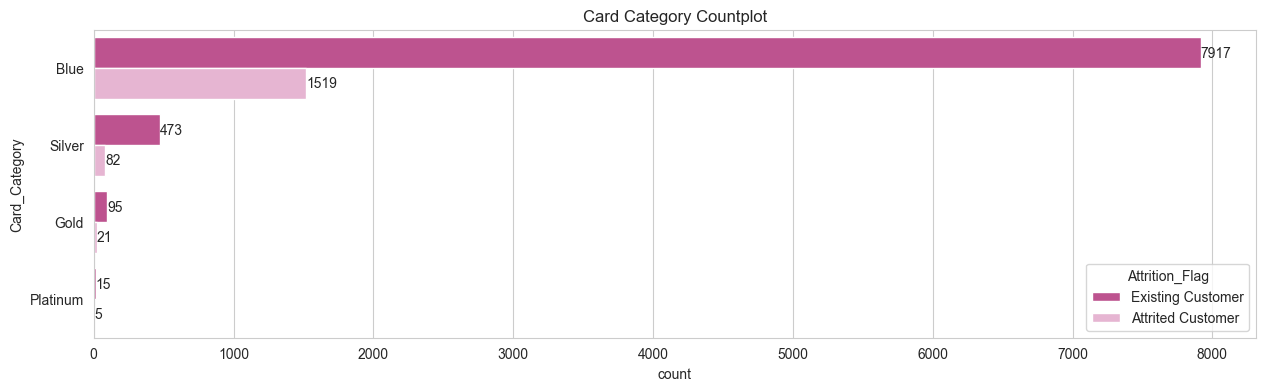

In [11]:
# Set order of the Card_Category variable
card_category_order = [
    "Blue",
    "Silver",
    "Gold",
    "Platinum"
]

# Plot horizontal countplot for better visualisation of smaller values in the Card_Category variable
plt.figure(figsize=(15, 4))
ax_card = sns.countplot(data=df_vis, y="Card_Category", hue="Attrition_Flag", order=card_category_order)
ax_card.bar_label(ax_card.containers[0])
ax_card.bar_label(ax_card.containers[1])
sns.move_legend(ax_card, "lower right")
plt.title("Card Category Countplot")

plt.show()

> *Notes on Process*:
<br><br>I wanted to add labels to each bar to show the number of clients in each income category. I found the following [Stack Overflow](https://stackoverflow.com/questions/55104819/display-count-on-top-of-seaborn-barplot) forum which was incredibly useful in helping me to find `ax.bar_label(ax.containers[0])`.
<br><br>

#### **1.3.2 Proportion Bar Chart**

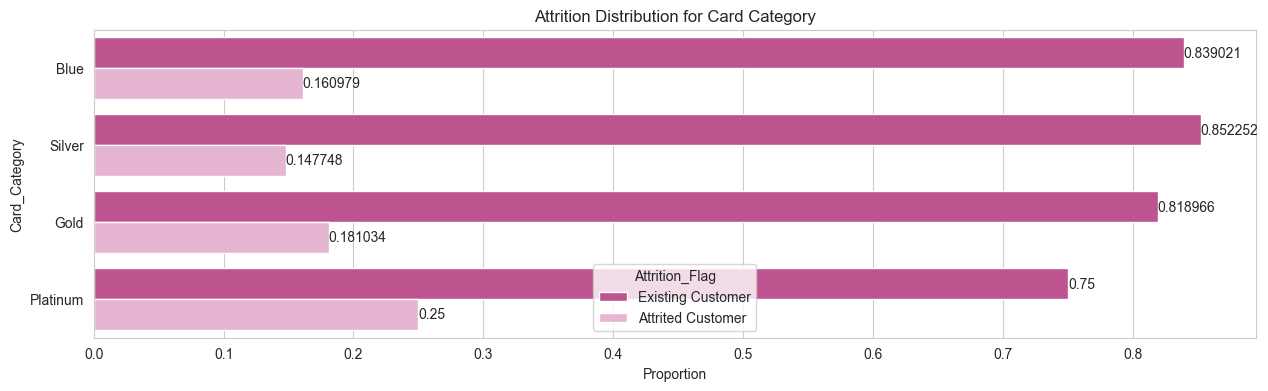

In [12]:
# Attrition_Flag Distribution by Card_Category
card_category_attrition_proportions = (df_vis.groupby("Card_Category")["Attrition_Flag"]
                                       .value_counts(normalize=True)
                                       .rename("Proportion")
                                       .reset_index())

plt.figure(figsize=(15, 4))
ax_card_prop = sns.barplot(data=card_category_attrition_proportions, x="Proportion", y="Card_Category", order=card_category_order, hue="Attrition_Flag")
ax_card_prop.bar_label(ax_card_prop.containers[0])
ax_card_prop.bar_label(ax_card_prop.containers[1])
sns.move_legend(ax_card_prop, "lower center")
plt.title("Attrition Distribution for Card Category")
plt.show()

##### **What does this proportion bar chart tell us?**

Once again, we see a similar proportionality to that of the `Attrition_Flag`, which suggests that again Card Category doesn't have a lot of bearing on whether a customer leaves the bank or not. 

### **1.4 Visualising Total Transaction Counts and Amounts**

The next thing I want to investigate is bank customers' transaction behaviour as an indication of their engagement. By plotting a scatterplot of transaction amounts and transaction counts, I want to get a clearer picture of *how* bank customers are using their cards. Understanding the relationship between these two variables will give me a picture of different types of customers. For example, frequent, low-value use will be a different customer profile to infrequent, high-value use customers. Whilst they both might appear engaged, the bank might want to treat them differently. 

> *Ethical Considerations*:
<br><br>There is a difference between using customer transaction behaviour as a basis to proactively offer better service (like a phone call from your branch, waiving a fee etc.) and using the same data to deny or restrict access to services.
<br><br>Whilst the analysis itself does not pull out any sensitive characteristics (we are only looking at spending patterns in this section), the dataset as a whole contains these characteristics (like `Gender`, `Income_Category` etc.). Even if this section doesn't directly use these variables, spending patterns could correlate to these other variables and therefore there could be instances where a conclusion is drawn that is biased against protected characteristics without ever *seeing* it explicitly. This **proxy discrimination** is a well-documented issue with banking information and so is worth flagging here.
<br><br>

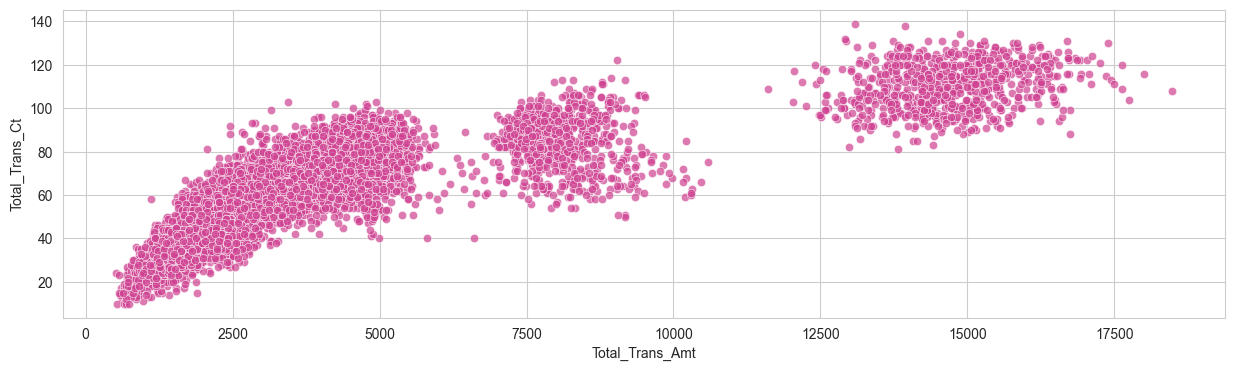

In [13]:
# Plot a scatterplot to show the relationship between Total Transaction Amount and Total Transaction Count
plt.figure(figsize=(15, 4))
sns.scatterplot(data=df_vis, x="Total_Trans_Amt", y="Total_Trans_Ct", alpha=0.7)
plt.show()

Having plotted this, I can see that there are some distinct groupings in the dataset. I will use `hue` to represent different variables in the dataset to see if there are any clear patterns for why these appear.

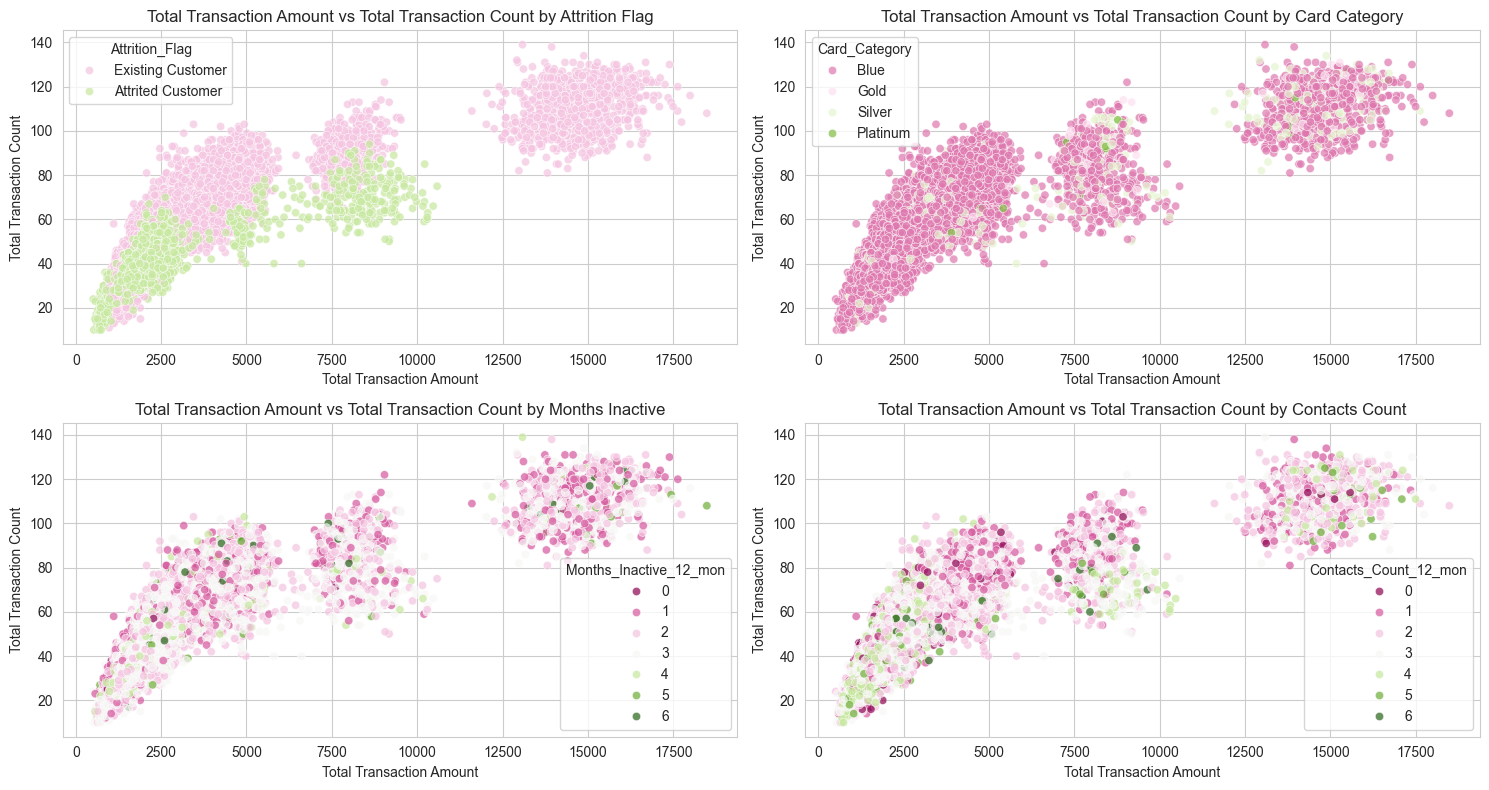

In [14]:
#Plot the same scatterplot, this time using hue to determine if the three significant groupings can be related to a specfic variable
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 8), tight_layout=True)

#Plot Total_Trans_Amt vs Total_Trans_Ct by Attrition_Flag
sns.scatterplot(data=df_vis, x="Total_Trans_Amt", y="Total_Trans_Ct", ax=axes[0,0], hue="Attrition_Flag", palette="PiYG", alpha=0.7)
axes[0,0].set_title("Total Transaction Amount vs Total Transaction Count by Attrition Flag")
axes[0,0].set_xlabel("Total Transaction Amount")
axes[0,0].set_ylabel("Total Transaction Count")

#Plot Total_Trans_Amt vs Total_Trans_Ct by Card_Category
sns.scatterplot(data=df_vis, x="Total_Trans_Amt", y="Total_Trans_Ct", ax=axes[0,1], hue="Card_Category", palette="PiYG", alpha=0.7)
axes[0,1].set_title("Total Transaction Amount vs Total Transaction Count by Card Category")
axes[0,1].set_xlabel("Total Transaction Amount")
axes[0,1].set_ylabel("Total Transaction Count")

#Plot Total_Trans_Amt vs Total_Trans_Ct by Months_Inactive_12_mon
sns.scatterplot(data=df_vis, x="Total_Trans_Amt", y="Total_Trans_Ct", ax=axes[1,0], hue="Months_Inactive_12_mon", palette="PiYG", alpha=0.7)
axes[1,0].set_title("Total Transaction Amount vs Total Transaction Count by Months Inactive")
axes[1,0].set_xlabel("Total Transaction Amount")
axes[1,0].set_ylabel("Total Transaction Count")

#Plot Total_Trans_Amt vs Total_Trans_Ct by Contacts_Count_12_mon
sns.scatterplot(data=df_vis, x="Total_Trans_Amt", y="Total_Trans_Ct", ax=axes[1,1], hue="Contacts_Count_12_mon", palette="PiYG", alpha=0.7)
axes[1,1].set_title("Total Transaction Amount vs Total Transaction Count by Contacts Count")
axes[1,1].set_xlabel("Total Transaction Amount")
axes[1,1].set_ylabel("Total Transaction Count")

plt.show()

> *Notes on Process*:
<br><br>I decided to set individual palettes for these scatterplots rather than use the globally-set palette because I felt the global palette didn't give the colour variation necessary to see the hue variable properly.
<br><br>

Ultimately, the `hue` variables weren't able to add additional insight into the three separate groups in the scatterplot. `Attrition_Flag` was the best example of groupings, but didn't match the groupings in the scatterplot.

What we can tell from the `Attrition_Flag` hue is that attrited customers sit at the lower end of total transaction amounts and counts.

---

## **2. Hypothesis Testing**

I am now going to use statistical tests and visualisations to analyse three hypotheses.

| **Hypothesis** | **Hypothesis Description** |
| -------------- | -------------------------- |
| **H1** | Customers who make more transactions tend to spend more |
| **H2** | Annual income category is linked to whether a customer leaves the bank |
| **H3** | Customers who leave the bank have a different revolving balance than those who remain |

### **2.1 Hypothesis 1: Customers who make more transactions tend to spend more**

| **Hypothesis** | **Description** |
| -------------- | --------------- |
| **H0** | There is no relationship between how much customers spend and how often they transact |
| **H1** | Customers who make more transactions tend to spend more |

#### **2.1.1 Shapiro-Wilk Normal Distribution Test**

The first thing I will do is carry out a Shapiro-Wilk test to see if the data in both columns is normally distributed.
* In this process, I will be setting alpha to 0.05
* If the p-value is less than the alpha of 0.05, I can reject the null hypothesis (that the data is normally distributed) and conclude that the data is not normally distributed.

In [15]:
# Test whether previous_grade is normally distributed using the Shapiro-Wilk test
print("="*60)
print("SHAPIRO-WILK TEST FOR NORMALITY - TRANSACTION AMOUNT")
print("="*60)
trans_amt_normality = pg.normality(df_vis["Total_Trans_Amt"], alpha=0.05)
print(trans_amt_normality)
print("\n")

print("="*60)
print("SHAPIRO-WILK TEST FOR NORMALITY - TRANSACTION COUNT")
print("="*60)
trans_ct_normality = pg.normality(df_vis["Total_Trans_Ct"], alpha=0.05)
print(trans_ct_normality)

SHAPIRO-WILK TEST FOR NORMALITY - TRANSACTION AMOUNT
                        W          pval  normal
Total_Trans_Amt  0.746531  4.732422e-82   False


SHAPIRO-WILK TEST FOR NORMALITY - TRANSACTION COUNT
                       W          pval  normal
Total_Trans_Ct  0.983915  2.886753e-32   False


/Users/elliebrawn/Documents/vscode-projects/credit-card-customer-churn-analysis/.venv/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10127.
  res = hypotest_fun_out(*samples, **kwds)
/Users/elliebrawn/Documents/vscode-projects/credit-card-customer-churn-analysis/.venv/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10127.
  res = hypotest_fun_out(*samples, **kwds)


> *Troubleshooting Issues*:
<br><br>When I ran this Shapiro-Wilk Test, I got the following error: *"UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10127."*
<br><br>This was a warning I had not seen previously (my last project had a dataset about a tenth of the size of this current one). By consulting the [SciPy Shapiro Documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.shapiro.html), I found that this was an error message that is to be expected: *"For N > 5000 the W test statistic (measuring how well the data fits a normal distribution) is accurate, but the p-value may not be"*.
<br><br>Generative AI (Claude Sonnet 5) was helpful in suggesting alternative ways of ascertaining whether the data is normal - namely that of visualising the data in a Q-Q plot alongside histograms.
<br><br>

Essentially, whilst the p-values suggest that the results are highly statistically significant (much lower than the alpha of 0.05), the size of the dataset makes the p-value an unreliable metric and therefore, we cannot say that the data has a normal distribution.

#### **2.1.2 Q-Q Plot to Visualise Distribution**

As a result, I am going to plot a histogram and a Q-plot for both `Total_Trans_Amt` and `Total_Trans_Ct` to visualise the distribution. 

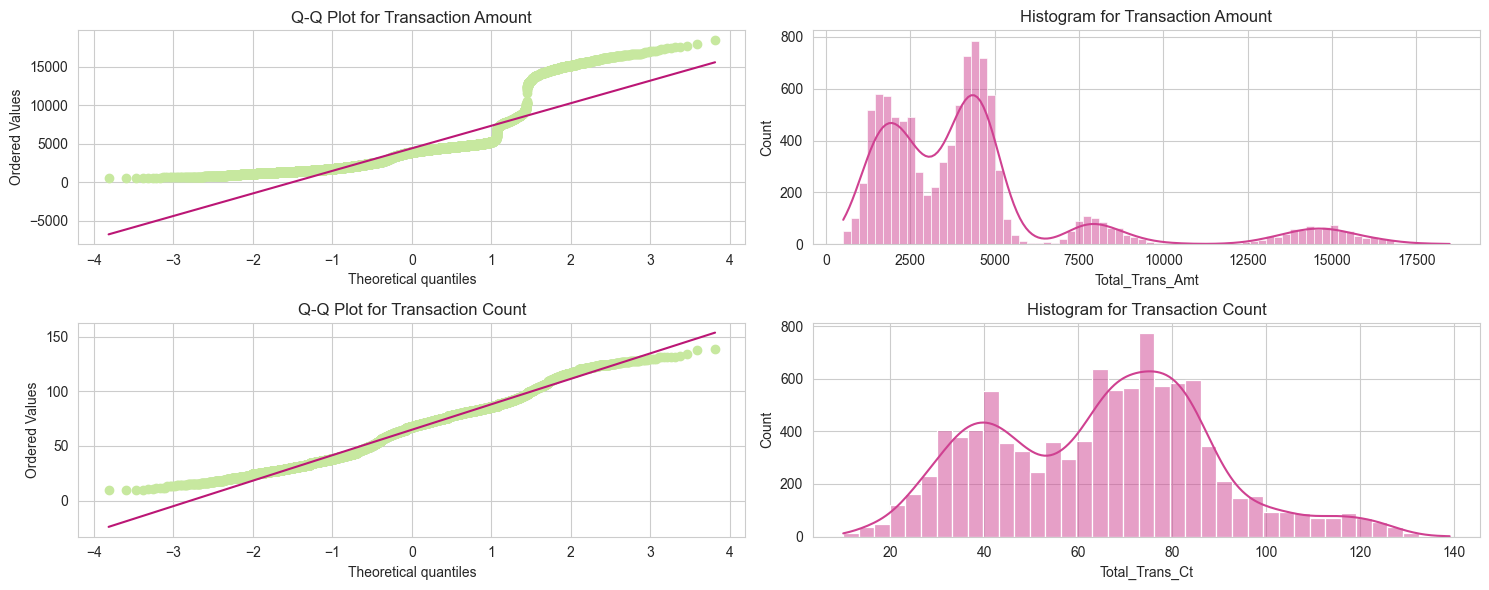

In [16]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 6), tight_layout=True)

# Plot a Q-Q plot for the Total_Trans_Amt variable
stats.probplot(df_vis["Total_Trans_Amt"], dist="norm", plot=axes[0,0])
axes[0,0].set_title("Q-Q Plot for Transaction Amount")
axes[0,0].get_lines()[1].set_color("#BB1675")  # Set the colour of the Q-Q line
axes[0,0].get_lines()[0].set_color("#C7E89F") # Set the colour of the data points

# Plot a histogram for the Total_Trans_Amt variable
sns.histplot(data=df_vis["Total_Trans_Amt"], kde=True, ax=axes[0,1])
axes[0,1].set_title("Histogram for Transaction Amount")

# Plot a Q-Q plot for the Total_Trans_Ct variable
stats.probplot(df_vis["Total_Trans_Ct"], dist="norm", plot=axes[1,0])
axes[1,0].set_title("Q-Q Plot for Transaction Count")
axes[1,0].get_lines()[1].set_color("#BB1675")  # Set the color of the Q-Q line
axes[1,0].get_lines()[0].set_color("#C7E89F") # Set the color of the data points

# Plot a histogram for the Total_Trans_Ct variable
sns.histplot(data=df_vis["Total_Trans_Ct"], kde=True, ax=axes[1,1])
axes[1,1].set_title("Histogram for Transaction Count")

plt.show()

> *Notes on Process*:
<br><br>A very helpful [Stack Overflow](https://stackoverflow.com/questions/37463189/change-marker-style-color-in-python-probplot) forum helped me to work out how to change the colours in this Q-Q plot to match the other visualisations in my Jupyter Notebook.
<br><br>

As we can see from the Q-Q plots and histograms, neither `Total_Trans_Amt` nor `Total_Trans_Ct` are normally distributed. Both Q-Q plots curve away from the straight line (normal) at the tails. Furthermore, the histograms are not unimodal, which is a requirement for normal distribution. Given what we have seen in both the Shapiro-Wilk Test and, more importantly, the Q-Q plots and histograms, these variables are not normally distributed and means we will use a Spearman correlation test in the next section.

#### **2.1.3 Perform Correlation Testing and Visualise**

Because of the lack of normality in the data, Spearman will be used as the primary test and Pearson will be used as a robustness check.

In [17]:
# Calculate the Spearman's correlation coefficient (rho) and p-value
rho, p = stats.spearmanr(df_vis["Total_Trans_Amt"], df_vis["Total_Trans_Ct"])
print("="*42)
print("SPEARMAN'S CORRELATION ANALYSIS")
print("="*42)
print(f"Spearman's Correlation Coefficient: {rho:.3f}")
print(f"p-value: {p:.2e}\n")

# Calculate the Pearson's correlation coefficient (r) and p-value
r, p = stats.pearsonr(df_vis["Total_Trans_Amt"], df_vis["Total_Trans_Ct"])
print("="*42)
print("PEARSON CORRELATION ANALYSIS")
print("="*42)
print(f"Pearson Correlation Coefficient: {r:.3f}")
print(f"p-value: {p:.2e}")

SPEARMAN'S CORRELATION ANALYSIS
Spearman's Correlation Coefficient: 0.880
p-value: 0.00e+00

PEARSON CORRELATION ANALYSIS
Pearson Correlation Coefficient: 0.807
p-value: 0.00e+00


##### **Interpreting the Coefficients and p-values**

Both tests agree closely: this means that both correlation tests are reading the same underlying correlation signal. 

*Interpreting the Coefficient **rho***:
* A Spearman's Correlation Coefficient of 0.880 supports the H1 hypothesis in terms of direction: as `Total_Trans_Ct` goes up, so does `Total_Trans_Amt`.
* rho ranges from -1 to +1: +0.880 demonstrates a strong positive correlation
* Because Spearman's correlation looks at rank rather than a strictly linear relationship, we can say the relationship between the total transaction amounts and the number of transactions is strongly **monotonic**: customers who *rank* higher in total transaction amount also tend to *rank* higher in transaction count.

*Interpreting the Coefficient **r***:
* A Pearson Correlation Coefficient of 0.807 is a strong positive linear relationship. It suggests that *as `Total_Trans_Ct` increases, `Total_Trans_Amt` increases in a fairly linear manner.

*Interpreting the two Coefficients **rho** vs **r***:
* The **r** coefficient is slightly lower than the **rho** coefficient: given what we already know about the data distribution, that rings true. 
* The fact that Spearman's **rho** is higher than the Pearson **r** suggests the relationship is monotonic but not perfectly linear.
* However, both still support the H1 hypothesis in terms of positive correlation.

*Interpreting the p-values*:
* So now the question is whether the relationships that the Spearman and Pearson tests show are **statistically significant**.
* In both instances, the p-values are incredibly small (p-value < 0.001) - lower than our alpha of 0.05 and emphatically demonstrating that this relationship is statistically significant and can be used to reject the null hypothesis. 
* What is interesting is that both correlation tests have a p-value displayed as 0.00e+00. I chose to try and display the p-values with floating-point precision rather than simple decimals because I wanted to see how small the numbers were (how close to truly being 0).
* The fact that the numbers are still shown as 0.00e+00 means that they are too small for scipy to represent and so it rounds it to 0.00.

##### **Visualising the Relationship**

When visualising my data, I am going to use two different regression plots using seaborn regplot. 
* The first will be a standard regplot that assumes a straight-line linear relationship (which is what Pearson is testing)
* The second will be a LOWESS (LOcally WEighted Scatterplot Smoothing) regplot, which draws a line to follow the actual shape of the trend (more akin to what Spearman is measuring) 

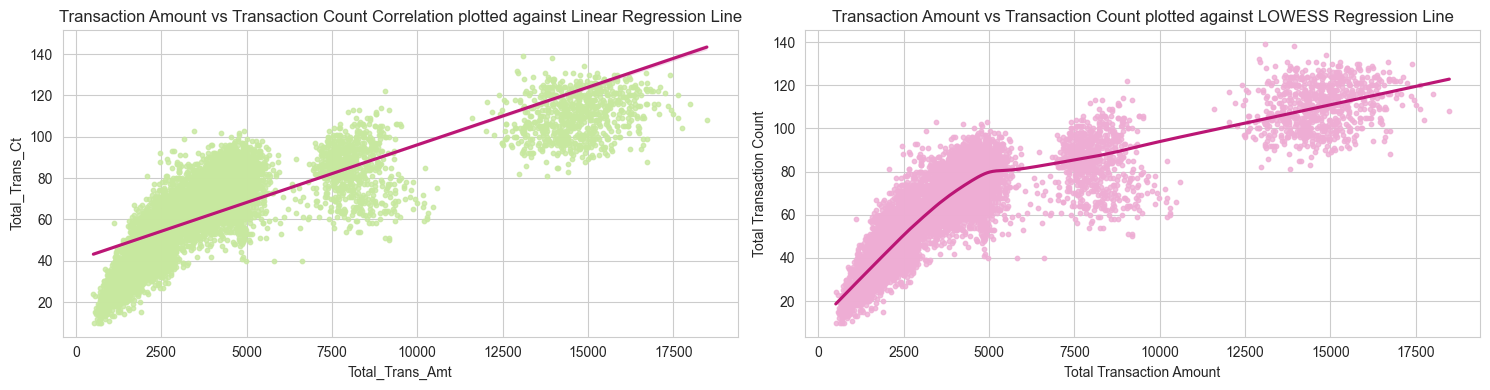

In [18]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 4), tight_layout=True)

# Plot a linear regression line on a scatter plot to visualize the relationship between Total_Trans_Amt and Total_Trans_Ct
sns.regplot(data=df_vis, x="Total_Trans_Amt", y="Total_Trans_Ct", ax=axes[0], scatter_kws={"s": 10, "color": "#C7E89F"}, line_kws={"color": "#BB1675"})
axes[0].set_title("Transaction Amount vs Transaction Count Correlation plotted against Linear Regression Line")
plt.xlabel("Total Transaction Amount")
plt.ylabel("Total Transaction Count")

# Plot a LOWESS regression line on a scatter plot to visualize the relationship between Total_Trans_Amt and Total_Trans_Ct
sns.regplot(data=df_vis, x="Total_Trans_Amt", y="Total_Trans_Ct", ax=axes[1], lowess=True, scatter_kws={"s": 10, "color": "#EEADD4"}, line_kws={"color": "#BB1675"})
axes[1].set_title("Transaction Amount vs Transaction Count plotted against LOWESS Regression Line")
plt.xlabel("Total Transaction Amount")
plt.ylabel("Total Transaction Count")

plt.show()

#### **2.1.4 Summary**

The alternative hypothesis - **H1: Customers who make more transactions tend to spend more** - is supported because the p-value of the Spearman correlation test is well below the alpha of 0.05. This is supported by the coefficient **rho** being so high, indicating that there is a very strong positive correlation between transaction count and transaction amount. 

### **2.2 Hypothesis 2: Annual income category is linked to whether a customer leaves the bank**

| **Hypothesis** | **Description** |
| -------------- | --------------- |
| **H0** | Annual income category has no bearing on whether a customer leaves the bank |
| **H1** | Annual income category is linked to whether a customer leaves the bank - some income bands have noticeably higher or lower attrition rates than others |

Because we are analysing two categorical variables - `Income_Category` and `Attrition_Flag`, I will be using a Chi-Squared Test.

#### **2.2.1 Plot a countplot to visualise Income Category by Attrition Flag**

First, I am going to investigate the attrition flags across each income category.

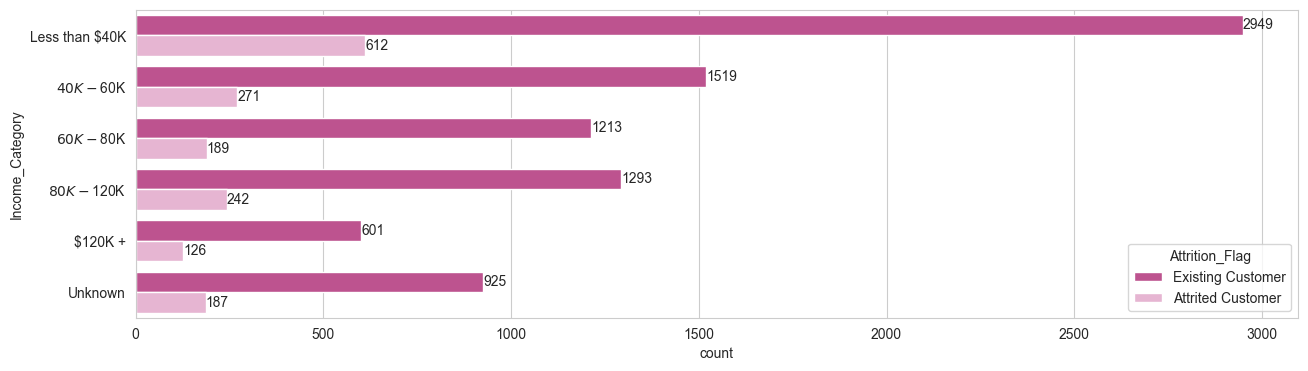

In [19]:
# Set order of the Income_Category variable
income_category_order = [
    "Less than $40K",
    "$40K - $60K",
    "$60K - $80K",
    "$80K - $120K",
    "$120K +",
    "Unknown"
]

# Plot a seaborn countplot which looks at the relationship between Income_Category and Attrition_Flag

plt.figure(figsize=(15, 4))
ax_ic = sns.countplot(data=df_vis, y="Income_Category", hue="Attrition_Flag", order=income_category_order)
ax_ic.bar_label(ax_ic.containers[0])
ax_ic.bar_label(ax_ic.containers[1])
sns.move_legend(ax_ic, "lower right")

plt.show()

> *Notes on Process*:
<br><br>I wanted to moved the hue legend, which overlapped some of the bars. I used the official [Seaborn Documentation](https://seaborn.pydata.org/generated/seaborn.move_legend.html) for `.move_legend` to make this happen.
<br><br>

Looking at this countplot, it is difficult to ascertain whether income category has a bearing on whether a customer is still a cient or has attrited.

I will investigate this further by performing a Chi-Squared Test.

#### **2.2.2 Chi-Squared Test**

As mentioned before, I have chosen to perform a Chi-Squared Test to determine whether there is an association between the two categories I am investigating.

The target variable that I am interested in analysing is `Income_Category` across the given feature `Attrition_Flag`. 

In [20]:
# Perform a chi-squared test between Card_Category and Attrition_Flag
expected, observed, statistics = pg.chi2_independence(data=df_vis, x="Income_Category", y="Attrition_Flag")

# Call statistics to display the results of the chi-squared test
statistics

,test,lambda,chi2,dof,pval,cramer,power
0,pearson,1.000000,12.832259,5.0,0.025002,0.035597,0.800167
1,cressie-read,0.666667,12.916865,5.0,0.024170,0.035714,0.803176
2,log-likelihood,0.000000,13.097047,5.0,0.022486,0.035962,0.809464
3,freeman-tukey,-0.500000,13.242224,5.0,0.021212,0.036161,0.814412
4,mod-log-likelihood,-1.000000,13.396453,5.0,0.019934,0.036371,0.819556
5,neyman,-2.000000,13.733815,5.0,0.017392,0.036826,0.830406


> *Troubleshooting Issues*:
<br><br>When I first ran this, I used the variable name `stats` instead of `statistics` - this then replaced my import code `from scipy import stats`. As a note to self, be careful about variable names and what you call them.
<br><br>

In the table above, we are interested in two specific entries `pearson chi-test | p-val` and `pearson chi-test | cramer`.

| **Test** | **Column** | **Column Value** | **What does this show?** |
| ----- | ------- | -------- | ------- |
| `pearson` | `pval` | 0.025002 | Since p-values range from 0 to 1, where a value less than alpha=0.05 rejects the null hypothesis, a p-value of 0.025002 means that the pattern we see in the data is statistically significant. | 
|`pearson` | `cramer` | 0.035597 | Cramer's V demonstrates the strength of the relationship between two variables. It is also measured between 0 and 1, where 0 = no association between categorical variables and 1 = perfect association. As we can see, Cramer's V is  close to 0 (0.027131), meaning the relationship between `Income_Category` and `Attrition_Flag` is very weak. |

#### **2.2.3 Summary**

In conclusion, even though the test indicates a significant association between `Income_Category` and `Attrition_Flag` (with a p-value of 0.025), the effect size is insignificant (Cramer's V = 0.036). This suggests that income category has very limited practical value in explaining or predicting customer attrition.

The alternative hypothesis - **H2: Annual income category is linked to whether a customer leaves the bank** - is supported because the p-value is below alpha but the association between the two is very weak.

### **2.3 Hypothesis 3: Customers who leave the bank have a different revolving balance than those who remain**

| **Hypothesis** | **Description** |
| -------------- | --------------- |
| **H0** | Customers who leave the bank have roughly the same revolving balance as customers who stay |
| **H3** | Customers who leave the bank have a different revolving balance than those who remain |

#### **2.3.1 Split the Data**

In order to conduct this test, I need to split the data we are using into two distinct groups:

1. Revolving Balance of *existing* customers
2. Revolving Balance of *attrited* customers

In [21]:
# Use .groupby to group the revolving balance by Attrition_Flag
grouped_attrition_revolving_bal = df_vis.groupby("Attrition_Flag")["Total_Revolving_Bal"]

# Create separate variables for each part-time job status group
existing_revolving_bal = grouped_attrition_revolving_bal.get_group("Existing Customer")
attrited_revolving_bal = grouped_attrition_revolving_bal.get_group("Attrited Customer")

##### **Plot the new variables on an overlayed histogram**

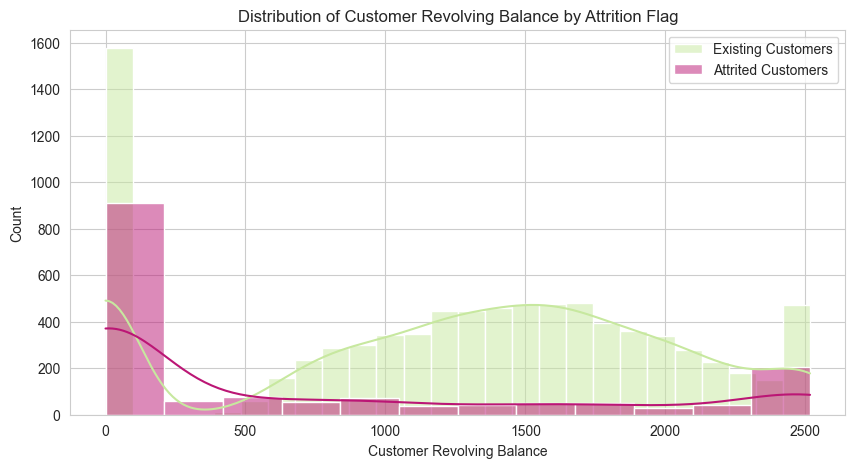

In [22]:
# Use seaborn to create two histograms of the distributions of the two variables
plt.figure(figsize=(10, 5))
sns.histplot(data=existing_revolving_bal, color="#C7E89F", alpha=0.5, label="Existing Customers", kde=True)
sns.histplot(data=attrited_revolving_bal, color="#BB1675", alpha=0.5, label="Attrited Customers", kde=True)
plt.title("Distribution of Customer Revolving Balance by Attrition Flag")
plt.xlabel("Customer Revolving Balance")
plt.legend()
plt.show()

#### **2.3.2 Preliminary Descriptive Statistics - Mean and Median**

In [24]:
# Find the mean revolving balance for existing and attrited customers
print("="*46)
print("MEAN REVOLVING BALANCE BY ATTRITION FLAG ($)")
print("="*46)
print(f"Existing customers: {existing_revolving_bal.mean():.2f}")
print(f"Attrited customers: {attrited_revolving_bal.mean():.2f}")
print("")
# Find the median revolving balance for existing and attrited customers
print("="*46)
print("MEDIAN REVOLVING BALANCE BY ATTRITION FLAG ($)")
print("="*46)
print(f"Existing customers: {existing_revolving_bal.median():.2f}")
print(f"Attrited customers: {attrited_revolving_bal.median():.2f}")

MEAN REVOLVING BALANCE BY ATTRITION FLAG ($)
Existing customers: 1256.60
Attrited customers: 672.82

MEDIAN REVOLVING BALANCE BY ATTRITION FLAG ($)
Existing customers: 1364.00
Attrited customers: 0.00


These preliminary findings show something interesting, particularly with regards to the attrited customers. 

For the median revolving balance to be $0.00, it means that more than half of the attrited customers have a revolving balance of $0.00. Because the mean is $672.82, this shows that there is a large cluster of customers with a revolving balance of $0.00 with a smaller number with higher revolving balances that pull the mean upwards. 

This fits a plausible narrative: customers who are about to leave the bank may pay-off their card and stop using it. By the time they are flagged as attrited their revolving balance has dropped to $0.00.

#### **2.2.3 Q-Q Plot to Visualise Distribution**

Because we saw that a Shapiro-Wilk Test works most effectively when N < 5000, I am going to use a Q-Q plot and a histogram like in **Hypothesis 1** to assess the distribution. The reason I am doing this is because this will affect whether I perform a t-test (a parametric test - for normally distributed data) or a Mann-Whitney U test (a non-parametric test - where at least one group is not normally distributed).

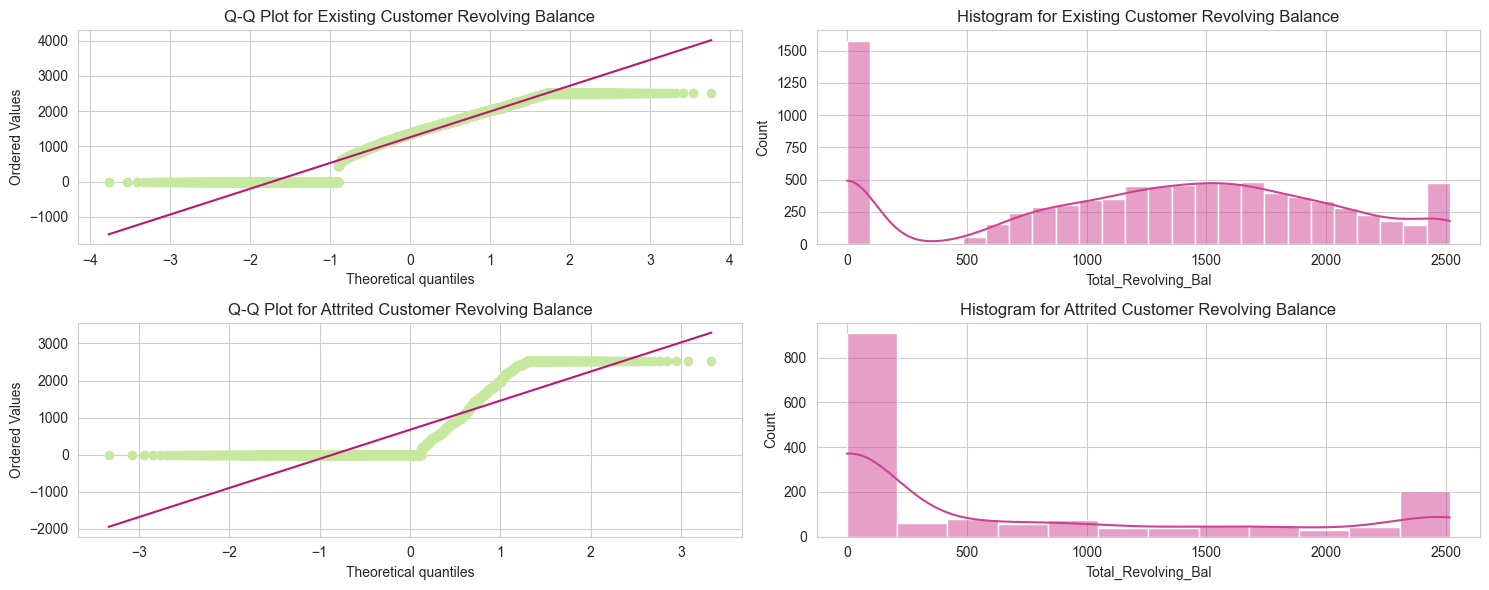

In [25]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 6), tight_layout=True)

# Plot a Q-Q plot for the existing_revolving_bal variable
stats.probplot(existing_revolving_bal, dist="norm", plot=axes[0,0])
axes[0,0].set_title("Q-Q Plot for Existing Customer Revolving Balance")
axes[0,0].get_lines()[1].set_color("#BB1675")  # Set the colour of the Q-Q line
axes[0,0].get_lines()[0].set_color("#C7E89F") # Set the colour of the data points

# Plot a histogram for the existing_revolving_bal variable
sns.histplot(data=existing_revolving_bal, kde=True, ax=axes[0,1])
axes[0,1].set_title("Histogram for Existing Customer Revolving Balance")

# Plot a Q-Q plot for the attrited_revolving_bal variable
stats.probplot(attrited_revolving_bal, dist="norm", plot=axes[1,0])
axes[1,0].set_title("Q-Q Plot for Attrited Customer Revolving Balance")
axes[1,0].get_lines()[1].set_color("#BB1675")  # Set the color of the Q-Q line
axes[1,0].get_lines()[0].set_color("#C7E89F") # Set the color of the data points

# Plot a histogram for the attrited_revolving_bal variable
sns.histplot(data=attrited_revolving_bal, kde=True, ax=axes[1,1])
axes[1,1].set_title("Histogram for Attrited Customer Revolving Balance")

plt.show()

As the visualisations show, neither are normally distributed, meaning I will perform a Mann-Whitney U test.

#### **2.2.4 Mann-Whitney U Test**

In [26]:
# Use pg.mwu() to perform a Mann-Whitney U test to compare the revolving balance of existing and attrited customers
print("="*70)
print("MAN-WHITNEY U TEST - REVOLVING BALANCE FOR EXISTING AND ATTRITED CUSTOMERS")
print("="*70)
print(pg.mwu(x=existing_revolving_bal, y=attrited_revolving_bal))

MAN-WHITNEY U TEST - REVOLVING BALANCE FOR EXISTING AND ATTRITED CUSTOMERS
         U-val alternative          p-val       RBC      CLES
MWU  9510716.0   two-sided  1.915679e-129  0.375424  0.687712


When judging the results from a Mann-Whitney U test, I have focused on the p-value, RBC and CLES.

| **Column** | **Column Value** | **What this shows** |
| ---------------- | ------- | ------------------ |
| p-value | 1.915679e-129 | The p-value is much *lower* than our alpha of 0.05, which means that this test revealed a statistically significant difference in the revolving balance of existing customers vs attrited customers. |
| RBC | 0.375424 | The RBC measures effect size and quantifies the strength and the direction of the difference between the two groups. An RBC of 0.375424 shows a moderate effect size and tells us the direction. Because it is a positive, it shows that the first group (`x=existing_revolving_bal`) tends to have higher values than the second group (`y=attrited_revolving_bal`). In other words, while it is a small effect, existing customers tend to have higher revolving balances than attrited customers. |
| CLES | 0.687712 | The CLES indicates the probability that a randomly-picked value from `x` (`x=existing_revolving_bal`) is higher than a randomly-picked value from `y` (`y=attrited_revolving_bal`). Because the CLES in this case is 0.687712, it means that this would happen roughly 68.8% of the time: this also points the same way as the RBC, that existing customers tend to have a higher revolving balance. | 

#### **2.2.5 Summary**

The alternative hypothesis - **H3: Customers who leave the bank have a different revolving balance than those who remain** - is supported because a Mann-Whitney U Test found a statistically significant difference in the revolving balances between existing and attrited customers (p-value is lower than the alpha of 0.05). The Mann-Whitney U Test was also able to show that the effect size was moderate (RBC = 0.375) and that existing customers had a 68.8% chance of having higher revolving balances than attrited customers (CLES = 0.688).

---

## **3. Conclusion**
In this notebook, I performed exploratory data analysis (EDA) and hypothesis testing.

### **3.1 EDA**
* I first analysed `Attrition_Flag`, given that the customer's attrition status (`Attrition_Flag_Binary`) is going to be the target variable in **Stage 4 - Machine Learning**. A countplot and pie chart demonstrated that the `Attrition_Flag` variable is very imbalanced, with `Existing Customers` making up nearly 84% of the dataset and `Attrited Customer` making up just over 16%. 
* I then explored demographic variables - `Gender`, `Marital_Status` and `Education_Level` - against attrition. A barplot showing the proportions of attrited vs existing customers in each demographic group indicated that the demographic variables were weak predictors of attrition.
* I performed the same analysis on `Card_Category`, plotting it against attrition. A barplot showing the proportions of attrited vs existing customers in each card category group indicated that it might not be a strong predictor of attrition.
* Finally, I visualised `Total_Trans_Amt` and `Total_Trans_Ct` to investigate customer transaction behaviour.

### **3.2 Hypothesis Testing**
Hypothesis 1 looked at whether customers who make more transactions tend to spend more.
* The Spearman coefficient of 0.880 confirmed a strong positive correlation between `Total_Trans_Ct` and `Total_Trans_amt`, meaning that as a customer makes more transactions, their total transaction amount goes up.
* The p-value was incredibly low (p-value < 0.001), demonstrating that this was a statistically significant correlation and thus the null hypothesis was rejected.
* **Hypothesis 1 was satisfied**.

Hypothesis 2 analysed whether a customer's annual income category is linked to whether they leave the bank.
* A Chi-squared test of independence was used to examine whether `Income_Category` was associated with `Attrition_Flag`.
* With a p-value below the alpha=0.05, the test determined there to be a statistically significant association between the variables *but* found this association to be very weak (Cramer's V = 0.036).
* The null hypothesis of independence was rejected, but the results suggest that income category has a very small part in explaining or predicting attrition.
* **Hypothesis 2 was satisfied**.

Hypothesis 3 examined whether customers who leave the bank have a different revolving balance vs those who remain.
* A Mann-Whitney U test was performed and demonstrated a statistically significant (p-value = 1.915679e-129), moderate difference where existing customers have a 68.8% chance of holding a higher revolving balance compared to a randomly-selected attrited customer.
* **Hypothesis 3 was satisfied**.

Across all three of these hypotheses, statistical significance was found and the null hypothesis was rejected for each. However, the practical effect varied hugely and this demonstrates why it’s so important to report on this effect size alongside the p-value.